# 🏠 Optimización del Modelo de Viviendas (California)
En la Semana 2 logramos un error medio de unos $32,000. El objetivo de hoy es bajar esa cifra ajustando los hiperparámetros del **RandomForestRegressor**.

### ¿Qué ajustes probaremos?
1. **n_estimators:** ¿Mejora la precisión si pasamos de 100 a 300 árboles?
2. **max_features:** ¿Cuántas variables debe mirar la IA en cada rama? (auto, sqrt, log2).
3. **bootstrap:** Probar si usar todo el dataset o solo partes mejora la estabilidad.

**Ruta de datos:** `../../../data/processed/viviendas_limpio.csv`

In [2]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# 1. CARGA Y PREPARACIÓN (Como ya lo tienes)
path = '../../../data/processed/viviendas_limpio.csv'
df = pd.read_csv(path)
df_ml = pd.get_dummies(df, columns=['ocean_proximity'])

X = df_ml.drop('median_house_value', axis=1)
y = df_ml['median_house_value']

# 2. PANEL DE EXPERIMENTOS CORREGIDO
# [Explicación]: Hemos eliminado 'auto' para evitar el error de la librería.
# Usamos None (que equivale al antiguo 'auto', usa todas las variables) y 'sqrt'.
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_features': [None, 'sqrt', 'log2'], # 'None' sustituye a 'auto'
    'bootstrap': [True, False]
}

# 3. CONFIGURACIÓN DEL BUSCADOR
# [Explicación]: Mantenemos cv=3 para velocidad en el dataset de California.
grid_viviendas = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3, 
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# 4. EJECUCIÓN
print("⏳ Optimizando sin errores de parámetros... Analizando combinaciones válidas.")
grid_viviendas.fit(X, y)

# 5. REPORTE FINAL
mejor_error = abs(grid_viviendas.best_score_)
print("\n🏆 ¡OPTIMIZACIÓN LIMPIA COMPLETADA!")
print("-" * 40)
print(f"🥇 Mejores ajustes: {grid_viviendas.best_params_}")
print(f"💸 Error medio real (Promedio CV): ${mejor_error:,.2f}")

⏳ Optimizando sin errores de parámetros... Analizando combinaciones válidas.

🏆 ¡OPTIMIZACIÓN LIMPIA COMPLETADA!
----------------------------------------
🥇 Mejores ajustes: {'bootstrap': True, 'max_features': 'sqrt', 'n_estimators': 200}
💸 Error medio real (Promedio CV): $48,850.21


In [3]:
import joblib
import os

# 1. PREPARACIÓN DE RUTA
# [Explicación]: Guardamos en /models/ como la versión optimizada V2.
ruta_models = '../../../models/'
os.makedirs(ruta_models, exist_ok=True)
full_path = os.path.join(ruta_models, 'modelo_viviendas_optimizado_v2.pkl')

# 2. EXTRACCIÓN DEL MEJOR MODELO
# [Explicación]: Tomamos el modelo que ganó la competición del GridSearch.
mejor_modelo_viviendas = grid_viviendas.best_estimator_

# 3. PERSISTENCIA
joblib.dump(mejor_modelo_viviendas, full_path)

print(f"✅ Versión optimizada guardada con éxito en: {full_path}")

✅ Versión optimizada guardada con éxito en: ../../../models/modelo_viviendas_optimizado_v2.pkl


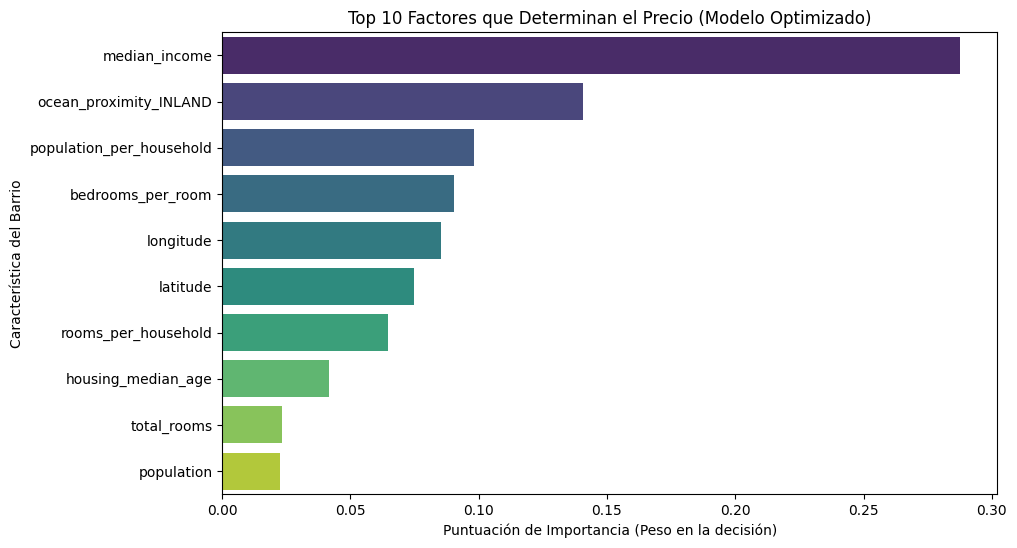

💡 La variable con mayor peso predictivo es: median_income


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. EXTRACCIÓN DE IMPORTANCIAS
# [Explicación]: Sacamos el "peso" que la IA le da a cada dato (Ingresos, Ubicación, etc.)
importancias = mejor_modelo_viviendas.feature_importances_
columnas = X.columns # X es el DataFrame de entrenamiento que usamos antes

# 2. CREACIÓN DE TABLA DE ANÁLISIS
# [Explicación]: Ordenamos de mayor a menor importancia.
df_imp = pd.DataFrame({'Variable': columnas, 'Importancia': importancias})
df_imp = df_imp.sort_values(by='Importancia', ascending=False).head(10)

# 3. GRÁFICO VISUAL
# [Explicación]: Usamos 'viridis' para un acabado estético y claro.
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_imp, hue='Variable', palette='viridis', legend=False)

plt.title('Top 10 Factores que Determinan el Precio (Modelo Optimizado)')
plt.xlabel('Puntuación de Importancia (Peso en la decisión)')
plt.ylabel('Característica del Barrio')
plt.show()

# 4. CONCLUSIÓN PARA EL INFORME
top_var = df_imp.iloc[0]['Variable']
print(f"💡 La variable con mayor peso predictivo es: {top_var}")